In [2]:
try:
    import torch 
    import torchvision
    assert int(torchvision.__version__.split(".")[1])>=25
    assert int(torch.__version__.split(".")[1])>=12
    print(f"torch version : {torch.__version__}")
    print(f"torchvision version : {torchvision.__version__}")

except:
    !pip3 install -U torch torchvision
    import torch
    import torchvision


torch version : 2.13.0+cpu
torchvision version : 0.28.0+cpu


In [3]:
import matplotlib.pyplot as plt 

from torch import nn
from torchvision import transforms
from torchinfo import summary

from going_modular import data_setup,engine

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [5]:
def set_seed(seed:int = 42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

In [6]:
import os 
import zipfile
import requests
from pathlib import Path

def download_data(source: str,
                  destination:str,
                  remove_source:bool = True):

    data_path = Path("data/")
    image_path = data_path / destination

    if image_path.is_dir():
        print(F"[info] {image_path} exist.")
    else:
        print(f"[info] {image_path} not found.")
        image_path.mkdir(parents=True,exist_ok=True)
        target_file = Path(source).name
        with open(data_path/target_file,"wb") as f:
            request = requests.get(source)
            print(f"downloading {target_file} from {source}")
            f.write(request.content)

        with zipfile.ZipFile(data_path/target_file,"r") as zip:
            print(f"[info] Unzipping {target_file} data")
            zip.extractall(image_path)

        if remove_source:
            os.remove(data_path/target_file)

    return image_path

Image_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                            destination="pizza_steak_sushi")

Image_path


[info] data\pizza_steak_sushi exist.


WindowsPath('data/pizza_steak_sushi')

In [7]:
train_dir = Image_path / "train"
test_dir = Image_path / "test"

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])

manual_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])
print(f"manual created transforms : {manual_transforms}")

train_dataloader,test_dataloader,class_name = data_setup.create_dataloaders(train_dir= train_dir,
                                                                            test_dir= test_dir,
                                                                            transform=manual_transforms,
                                                                            batch_size=32,)

train_dataloader,test_dataloader,class_name


manual created transforms : Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


(<torch.utils.data.dataloader.DataLoader at 0x1c70e8e30e0>,
 ['pizza', 'steak', 'sushi'])

In [8]:
# freezing pretrained model 
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
model = torchvision.models.efficientnet_b0(weights=weights).to(device)

In [9]:
for param in model.features.parameters():
    param.requires_grad = False

set_seed()

model.classifier = torch.nn.Sequential(
    nn.Dropout(p=0.2,inplace=True),
    nn.Linear(in_features=1280,
              out_features=len(class_name),
              bias=True).to(device)
)



In [10]:
summary(model,input_size=(32,3,224,224),col_names=["input_size","output_size","num_params","trainable"])

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #                   Trainable
EfficientNet                                            [32, 3, 224, 224]         [32, 3]                   --                        Partial
├─Sequential: 1-1                                       [32, 3, 224, 224]         [32, 1280, 7, 7]          --                        False
│    └─Conv2dNormActivation: 2-1                        [32, 3, 224, 224]         [32, 32, 112, 112]        --                        False
│    │    └─Conv2d: 3-1                                 [32, 3, 224, 224]         [32, 32, 112, 112]        (864)                     False
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        [32, 32, 112, 112]        (64)                      False
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        [32, 32, 112, 112]        --                        --
│    └─Sequential

In [11]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [12]:
try:
    from torch.utils.tensorboard import SummaryWriter
except:
    print("installing....")
    !pip3 install -q tensorboard
    from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter()

In [13]:
from typing import Dict,List
from tqdm.auto import tqdm

from going_modular.engine import train_step,test_step

def train(model:torch.nn.Module,
          train_dataloader : torch.utils.data.DataLoader,
          test_dataloader : torch.utils.data.DataLoader,
          loss_fn : torch.nn.Module,
          optimizer : torch.optim.Optimizer,
          epochs : int ,
          device :torch.device
          ) -> Dict[str,List]:

    results = {
        "train_loss" : [],
        "train_acc" : [],
        "test_loss" : [],
        "test_acc" : []
    }

    for epoch in tqdm(range(epochs)):
        train_loss,train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)

        test_loss,test_acc = test_step(model=model,
                                       dataloader=test_dataloader,
                                       loss_fn=loss_fn,
                                       device=device)

        print(
            f"Epoch : {epoch+1} |"
            f"train_loss: {train_loss:.4f} |"
            f"train_acc: {train_acc:.4f} |"
            f"test_loss: {test_loss:.4f} |"
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_loss)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        #adding tracking
        writer.add_scalars(main_tag="loss",
                           tag_scalar_dict={"train_loss":train_loss,
                                            "test_loss":test_loss},
                                            global_step=epoch)

        writer.add_scalars(main_tag="Accuracy",
                           tag_scalar_dict={"train_acc": train_acc,
                                            "test_acc": test_acc},
                                            global_step=epochs)

        writer.add_graph(model=model,
                         input_to_model=torch.rand(32,3,224,224).to(device))

    writer.close()

    return results

        
        

In [14]:
set_seed()
results = train(model=model,
                train_dataloader=train_dataloader,
                test_dataloader=test_dataloader,
                loss_fn=loss_fn,
                optimizer=optimizer,
                epochs=5,
                device=device)

  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
  0%|          | 0/5 [00:13<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
results

NameError: name 'results' is not defined

In [15]:
def create_writer(experiment_name: str,
                  model_name:str,
                  extra: str=None) -> torch.utils.tensorboard.writer.SummaryWriter():
    from datetime import datetime
    import os
    timestamp = datetime.now().strftime("%Y-%m-%d")
    if extra:
        log_dir = os.path.join("runs",timestamp,experiment_name,model_name,extra)
    else:
        log_dir =os.join.join("runs",timestamp,experiment_name,model_name)

    print(f"[info] created Summary to {log_dir}")
    return SummaryWriter(log_dir=log_dir)

In [16]:
exampe = create_writer("hu ha","huuhaaa","4d")

[info] created Summary to runs\2026-08-09\hu ha\huuhaaa\4d


In [ ]:
from typing import Dict,List
from tqdm.auto import tqdm

from going_modular.engine import train_step,test_step

def train(model:torch.nn.Module,
          train_dataloader : torch.utils.data.DataLoader,
          test_dataloader : torch.utils.data.DataLoader,
          loss_fn : torch.nn.Module,
          optimizer : torch.optim.Optimizer,
          epochs : int ,
          device :torch.device,
          writer:torch.utils.tensorboard.writer.SummaryWriter
          ) -> Dict[str,List]:

    results = {
        "train_loss" : [],
        "train_acc" : [],
        "test_loss" : [],
        "test_acc" : []
    }

    for epoch in tqdm(range(epochs)):
        train_loss,train_acc = train_step(model=model,
                                          dataloader=train_dataloader,
                                          loss_fn=loss_fn,
                                          optimizer=optimizer,
                                          device=device)

        test_loss,test_acc = test_step(model=model,
                                       dataloader=test_dataloader,
                                       loss_fn=loss_fn,
                                       device=device)

        print(
            f"Epoch : {epoch+1} |"
            f"train_loss: {train_loss:.4f} |"
            f"train_acc: {train_acc:.4f} |"
            f"test_loss: {test_loss:.4f} |"
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_loss)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

        #adding tracking
        if writer:
            writer.add_scalars(main_tag="loss",
                           tag_scalar_dict={"train_loss":train_loss,
                                            "test_loss":test_loss},
                                            global_step=epoch)

            writer.add_scalars(main_tag="Accuracy",
                           tag_scalar_dict={"train_acc": train_acc,
                                            "test_acc": test_acc},
                                            global_step=epochs)

            writer.add_graph(model=model,
                         input_to_model=torch.rand(32,3,224,224).to(device))

            writer.close()
        else:
            pass

    return results

        
        

In [18]:
data_10_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip",
                                     destination="pizza_steak_sushi")
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

[info] data\pizza_steak_sushi exist.
[info] data\pizza_steak_sushi_20_percent exist.


In [19]:
train_dir_10_percent = data_10_percent_path / "train"
train_dir_20_percent = data_20_percent_path / "train"

test_dir = data_10_percent_path / "test"

test_dir,train_dir_10_percent,train_dir_20_percent

(WindowsPath('data/pizza_steak_sushi/test'),
 WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/train'))

In [20]:
from torchvision import transforms
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], # values per colour channel [red, green, blue]
                                 std=[0.229, 0.224, 0.225])
simple_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    normalize
])

In [21]:
batch_size=32
train_dataloader_10_percent,test_dataloader,class_name = data_setup.create_dataloaders(train_dir_10_percent,test_dir,simple_transform,batch_size)
train_dataloader_20_percent,test_dataloader,class_name = data_setup.create_dataloaders(train_dir_20_percent,test_dir,simple_transform,batch_size)
len(train_dataloader_20_percent),len(train_dataloader_10_percent),len(test_dataloader),class_name

(15, 8, 3, ['pizza', 'steak', 'sushi'])

In [22]:
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights)
len(effnetb2.classifier.state_dict()["1.weight"][0])

1408

In [23]:
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [52]:
from torch import nn
# import torchvis

OUT_FEATURES = len(class_name)

def create_effnetb0():
    weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT
    model = torchvision.models.efficientnet_b0(weights=weights).to(device)

    for param in model.features.parameters():
        param.requires_grad = False

    set_seed()

    model.classifier[1].out_features = OUT_FEATURES

    model.name = "effnetb0"
    print(f"[info] created new {model.name} model")
    return model

def create_effnetb2():
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    model = torchvision.models.efficientnet_b2(weights=weights).to(device)

    for param in model.features.parameters():
        param.requires_grad = False

    set_seed()

    model.classifier[1].out_features = OUT_FEATURES

    model.name = "effnetb2"
    print(f"[info] created new {model.name} model")
    return model




In [60]:
effnetb0 = create_effnetb0()
summary(effnetb0,input_size=(32,3,224,224),col_names=["input_size"])
effnetb0.name

[info] created new effnetb0 model


'effnetb0'

In [56]:
effnetb2 = create_effnetb2()

[info] created new effnetb2 model


In [57]:
num_epochs = [5,10]
models = ["effnetb0","effnetb2"]
train_dataloader = {"data_10_percent": train_dataloader_10_percent,
                    "data_20_percent": train_dataloader_20_percent}

In [67]:
%%time
from going_modular.utils import save_model
set_seed(42)
experiment_no = 0

for dataloader_name,train_dataloader in train_dataloader.items():
    for epoch in num_epochs:
        for model_name in models:
            experiment_no += 1
            print(f"[info] Experiment number : {experiment_no}")
            print(f"[info] model : {model_name}")
            print(f"[info] Dataloader:{dataloader_name}")
            print(f"[info] number of epochs: {epoch}")

            if model_name == "effnetb0":
                model = create_effnetb0()
            else:
                model = create_effnetb2()

            loss_fn = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

            train(model=model,
                  train_dataloader=train_dataloader,
                  test_dataloader=test_dataloader,
                  loss_fn=loss_fn,
                  optimizer=optimizer,
                  epochs=epoch,
                  device=device,
                  writer=create_writer(dataloader_name,
                                       model_name,
                                       extra= f"{epoch}_epochs")
                                       )                  
            
            save_file_path = f"07_{model_name}_{dataloader_name}_{epoch}_epoch.pth"
            save_model(model,
                       "models",
                       save_file_path)
            print("-"*50 +"\n")


[info] Experiment number : 1
[info] model : effnetb0
[info] Dataloader:data_10_percent
[info] number of epochs: 5
[info] created new effnetb0 model
[info] created Summary to runs\2026-08-09\data_10_percent\effnetb0\5_epochs


  0%|          | 0/5 [00:00<?, ?it/s]c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch : 1 |train_loss: 6.4674 |train_acc: 0.1328 |test_loss: 5.8333 |test_acc: 0.0104


 20%|██        | 1/5 [00:27<01:51, 27.76s/it]

Epoch : 2 |train_loss: 4.0523 |train_acc: 0.2578 |test_loss: 3.4429 |test_acc: 0.2263


...

Epoch : 9 |train_loss: 0.7359 |train_acc: 0.7646 |test_loss: 1.0774 |test_acc: 0.7633


 90%|█████████ | 9/10 [08:50<01:01, 61.65s/it]

Epoch : 10 |train_loss: 0.6516 |train_acc: 0.8063 |test_loss: 0.9621 |test_acc: 0.8153


100%|██████████| 10/10 [09:49<00:00, 58.99s/it]

[INFO] Saving model to: models\07_effnetb2_data_20_percent_10_epoch.pth
--------------------------------------------------



In [71]:
best_model_path = "models/07_effnetb2_data_20_percent_10_epoch.pth"
best_model = create_effnetb2()
best_model.load_state_dict(torch.load(best_model_path))

[info] created new effnetb2 model


<All keys matched successfully>

In [72]:
from pathlib import Path
effnetb2_model_size = Path(best_model_path).stat().st_size // (1024*1024)
print(f"EfficientNetb2 feature extractor model size : {effnetb2_model_size} MB")

EfficientNetb2 feature extractor model size : 35 MB


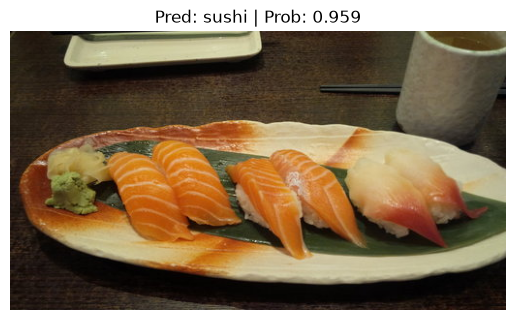

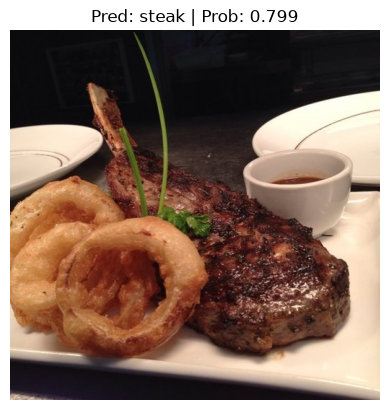

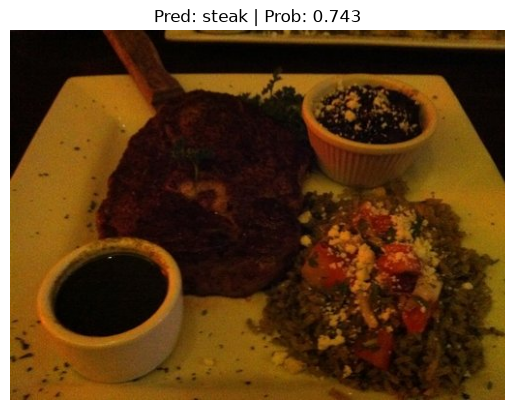

In [79]:
from going_modular.predictions import pred_and_plot_image
import random 
num_image_to_plot = 3
test_image_path_list = list(Path(data_20_percent_path/"test").glob("*/*jpg"))
test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=num_image_to_plot)

for image_path in test_image_path_sample:
    pred_and_plot_image(model=best_model,
                        image_path=image_path,
                        class_names=class_name,
                        image_size=(224,224))

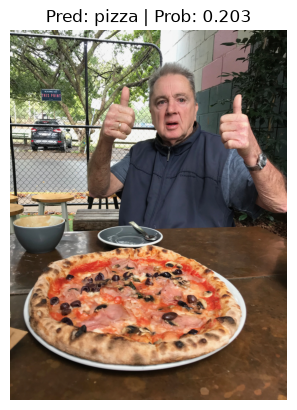

In [82]:
pred_and_plot_image(model=best_model,
                    image_path="data/04-pizza-dad.jpeg",
                    class_names=class_name)